# istat-gini-regionale — notebook v0

Notebook v0 di validazione del mart in `dataset-incubator`.

- scopo: sanity check e lettura base del mart
- non sostituisce l'analisi pubblica
- evitare output pesanti o immagini embeddate nel commit


In [7]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

SLUG = "istat_gini_regionale"
MART_TABLE = "mart_gini_regionale"
METRICA = "gini"

candidate_dir = Path.cwd()
if not (candidate_dir / "dataset.yml").exists():
    if (candidate_dir.parent / "dataset.yml").exists():
        candidate_dir = candidate_dir.parent
    else:
        raise FileNotFoundError(f"dataset.yml non trovato in {Path.cwd()} o nella cartella parent.")

mart_root = candidate_dir.parents[1] / "out" / "data" / "mart" / SLUG
mart_candidates = sorted(mart_root.glob(f"*/{MART_TABLE}.parquet"))
if not mart_candidates:
    raise FileNotFoundError(
        f"Mart non trovato per {SLUG}/{MART_TABLE} sotto {mart_root}. Eseguire prima toolkit run all."
    )

PARQUET_PATH = mart_candidates[-1]
print(f"Candidate dir: {candidate_dir.name}")
print(f"Mart table: {PARQUET_PATH.name}")

Candidate dir: istat-gini-regionale
Mart table: mart_gini_regionale.parquet


In [8]:
con = duckdb.connect()
df = con.execute("SELECT * FROM read_parquet(?)", [str(PARQUET_PATH)]).df()
print(f"Shape: {df.shape}")
display(df.dtypes)

Shape: (924, 4)


anno              int64
regione             str
pres_aff_imp      int64
gini            float64
dtype: object

In [9]:
display(df.head(10))

,anno,regione,pres_aff_imp,gini
0,2003,Abruzzo,1,0.271
1,2003,Abruzzo,2,0.296
2,2003,Basilicata,1,0.260
3,2003,Basilicata,2,0.279
4,2003,Calabria,1,0.305
5,2003,Calabria,2,0.324
6,2003,Campania,1,0.341
7,2003,Campania,2,0.360
8,2003,Emilia-Romagna,1,0.275
9,2003,Emilia-Romagna,2,0.309


In [10]:
print("Null per colonna:")
display(df.isnull().sum())

if METRICA in df.columns:
    negativi = int((df[METRICA] < 0).sum()) if pd.api.types.is_numeric_dtype(df[METRICA]) else "n/a"
    print(
        f"\nRange {METRICA}: min={df[METRICA].min()}, max={df[METRICA].max()}, negativi={negativi}"
    )
else:
    print(f"Metrica non trovata nel mart: {METRICA}")

print(f"\nAnni unici: {sorted(df['anno'].unique())}")
print(f"Regioni uniche: {len(df['regione'].unique())}")
print(f"pres_aff_imp unici: {sorted(df['pres_aff_imp'].unique())}")

Null per colonna:


anno            0
regione         0
pres_aff_imp    0
gini            0
dtype: int64


Range gini: min=0.225, max=0.396, negativi=0

Anni unici: [np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Regioni uniche: 22
pres_aff_imp unici: [np.int64(1), np.int64(2)]


In [11]:
# Confronto serie con/senza fitti imputati
if "pres_aff_imp" in df.columns and METRICA in df.columns:
    comparison = df.groupby(["anno", "pres_aff_imp"])[METRICA].mean().unstack()
    display(comparison)
    print("\nDifferenza media tra le due serie:")
    if len(comparison.columns) == 2:
        diff = comparison.iloc[:, 0] - comparison.iloc[:, 1]
        display(diff)

pres_aff_imp,1,2
anno,,
2003,0.284409,0.311500
2004,0.282909,0.312409
2005,0.275727,0.303409
2006,0.270727,0.306318
2007,0.268000,0.301591
2008,0.274045,0.307455
2009,0.270136,0.301773
2010,0.275000,0.309773
2011,0.275909,0.309364



Differenza media tra le due serie:


anno
2003   -0.027091
2004   -0.029500
2005   -0.027682
2006   -0.035591
2007   -0.033591
2008   -0.033409
2009   -0.031636
2010   -0.034773
2011   -0.033455
2012   -0.035045
2013   -0.033773
2014   -0.032500
2015   -0.032000
2016   -0.030864
2017   -0.032727
2018   -0.032773
2019   -0.031727
2020   -0.031773
2021   -0.033682
2022   -0.029773
2023   -0.029864
dtype: float64

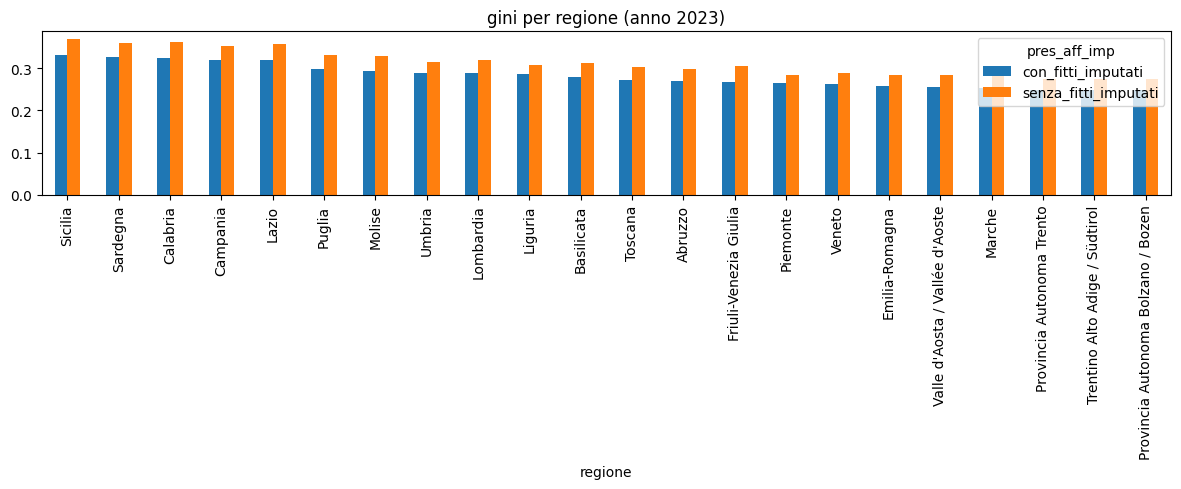

In [12]:
DIM = "regione"
latest = df[df["anno"] == df["anno"].max()].copy()
latest["pres_aff_imp"] = latest["pres_aff_imp"].astype(str)
chart = latest.pivot(index=DIM, columns="pres_aff_imp", values=METRICA).rename(
    columns={"1": "con_fitti_imputati", "2": "senza_fitti_imputati"}
)
sort_col = "con_fitti_imputati" if "con_fitti_imputati" in chart.columns else chart.columns[0]
chart = chart.sort_values(by=sort_col, ascending=False)
chart.plot(kind="bar", figsize=(12, 5), title=f"{METRICA} per {DIM} (anno {df['anno'].max()})")
plt.tight_layout()
plt.show()

## Note v0

- Slug: `istat-gini-regionale`
- Tabella mart: `mart_gini_regionale`
- Metrica guida: `gini`
- Perimetro: serie annuale regionale, 2003-2023, con/senza fitti imputati
- Questo notebook resta esplorativo e validativo in DI.
